# Bubble charts — intensités environnementales par sous-processus

Pour chaque catégorie de consommation (Food, Housing, Mobility, Final goods,
Final services), 3 bulles superposées (M_imp, M_row, M_dom) dont la taille est
proportionnelle à la demande finale associée. Agrégation par moyenne pondérée
via le bridge `M` de `bridge_matrices.xlsx` — voir `planefr_lib.plot_bubble`
pour le détail.

Deux figures :
1. Scénario de référence seul (`bubble_chart_reference_scenario_weighted.png`)
2. Comparaison base-year vs un scénario de transition (`bubble_chart_base_year_vs_<scénario>_weighted.png`)

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
if r"C:\Users\Arnaud\Documents\PlaneFR\notebooks" not in sys.path:
    sys.path.insert(0, r"C:\Users\Arnaud\Documents\PlaneFR\notebooks")

from planefr_lib import config, io
from planefr_lib.plot_bubble import prepare_bubble_dataset, plot_bubble_chart, plot_bubble_chart_comparison

## 1. Chargement des données communes

In [ ]:
facteurs_carac_df = io.load_facteurs_carac()
bridge_m = io.load_bridge_m_matrix()

scenario_folders = config.get_scenario_folders(exclude_2019=True)
reference_folder = scenario_folders[config.REFERENCE_SCENARIO_IDX]
print(f"Scénario de référence : {reference_folder.name}")
print(f"Bridge M : {bridge_m.shape}, catégories = {list(bridge_m.columns)}")

Scénario de référence : Base_year_2015
Bridge M : (200, 5), catégories = ['Food', 'Housing', 'Mobility', 'Final goods', 'Final services']


## 2. Bubble chart — scénario de référence

Sous-processus tracés : 7
Catégories : ['Food', 'Housing', 'Mobility', 'Final goods', 'Final services']


Figure sauvegardée : C:\Users\Arnaud\Documents\PlaneFR\figures\bubble_chart_reference_scenario_weighted.png


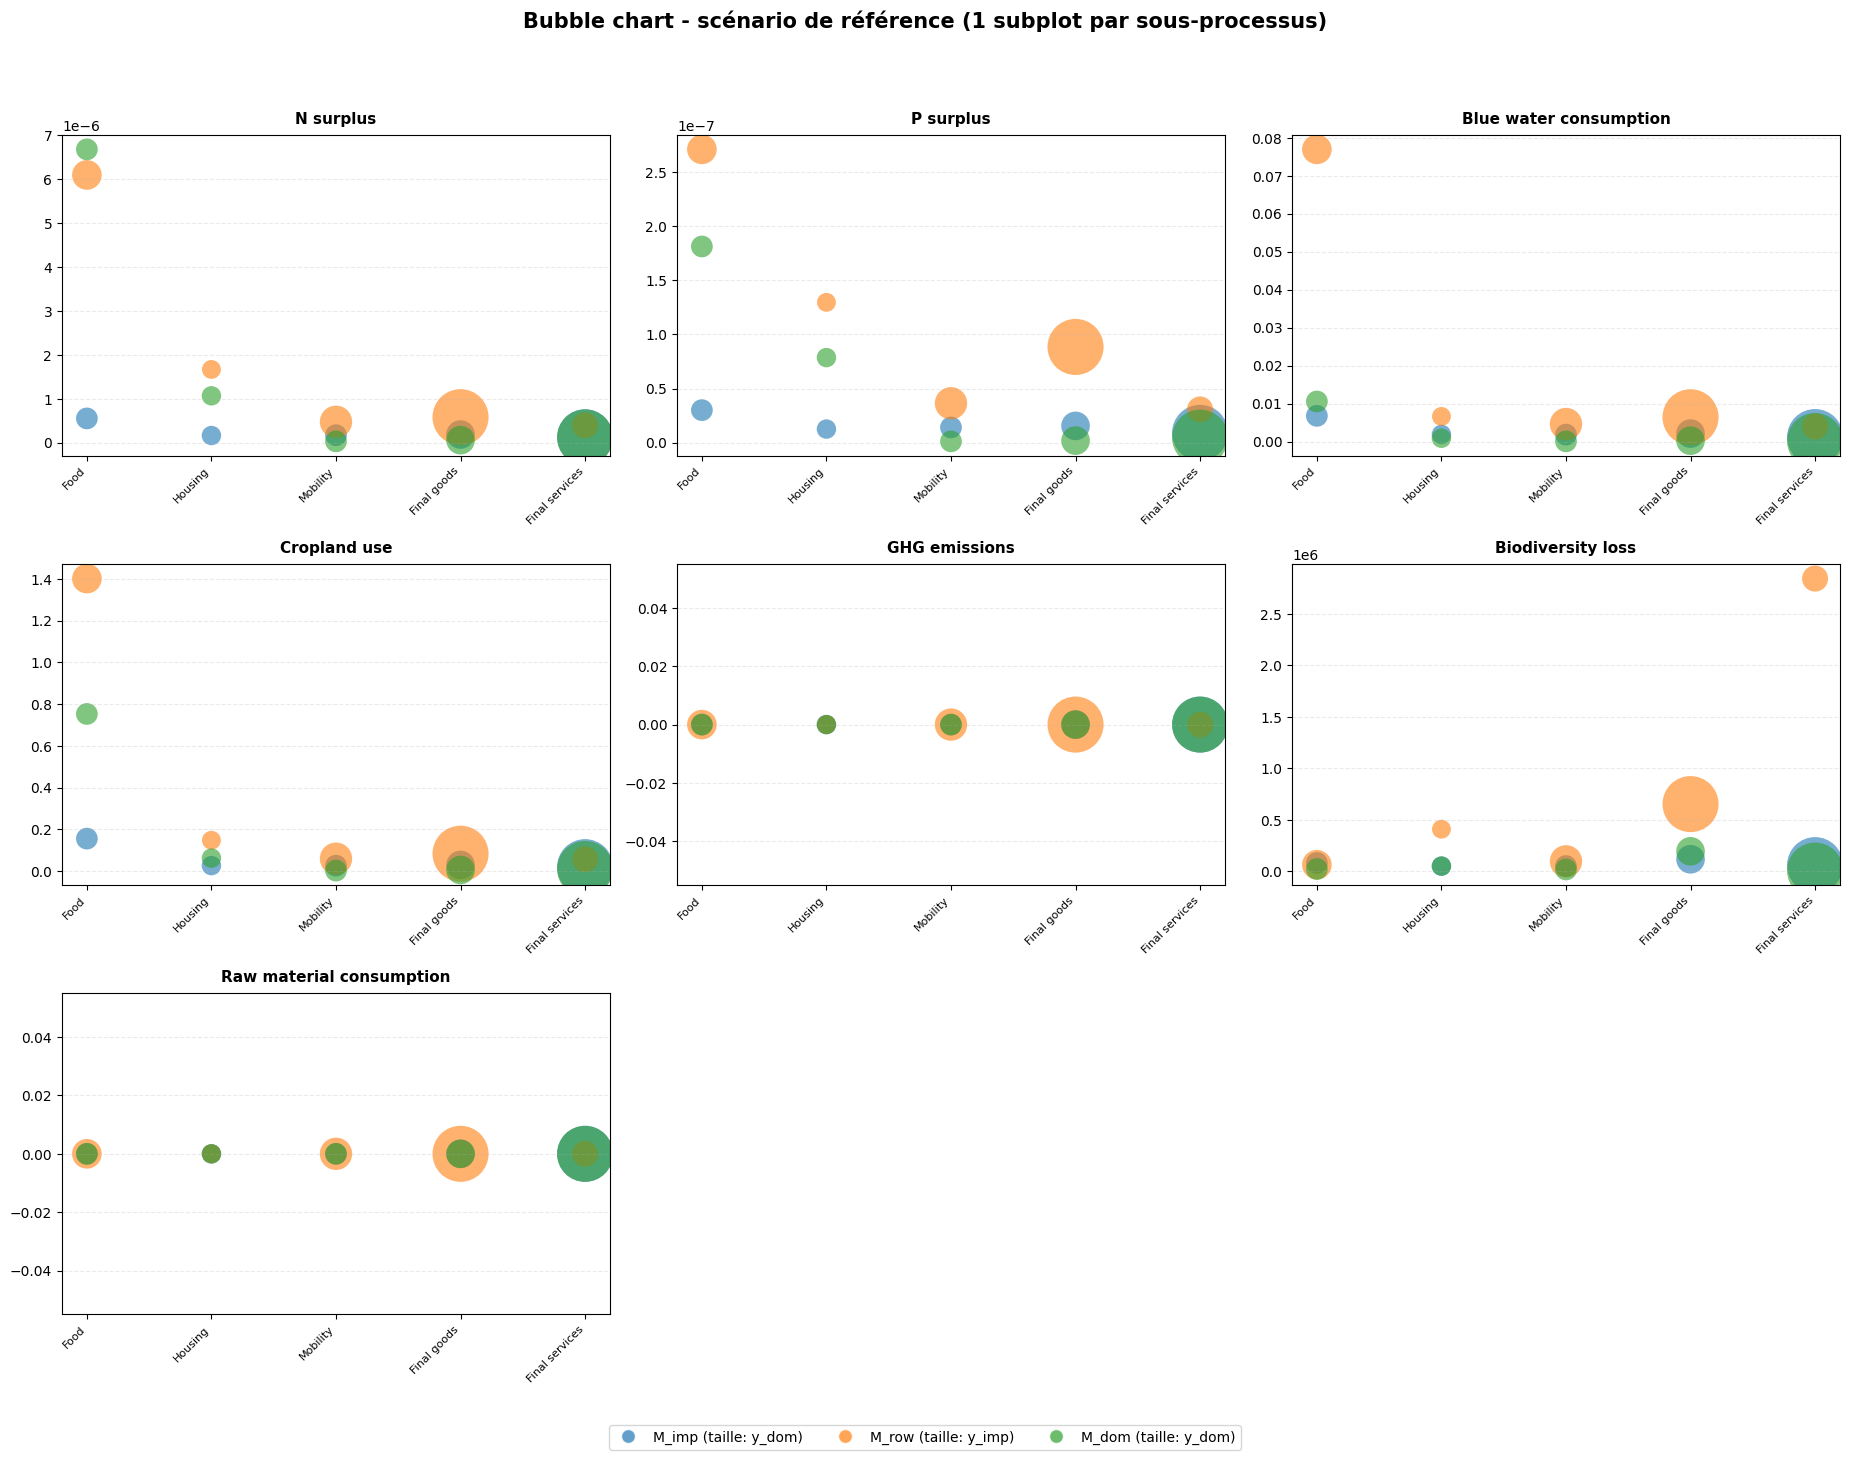

In [ ]:
data_bubble, y_dom_cat, y_imp_cat = prepare_bubble_dataset(reference_folder, facteurs_carac_df, bridge_m)
print(f"Sous-processus tracés : {len(data_bubble)}")
print(f"Catégories : {list(y_dom_cat.index)}")

fig_bubble, _ = plot_bubble_chart(data_bubble, y_dom_cat, y_imp_cat)

config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
output_path = config.FIGURES_DIR / "bubble_chart_reference_scenario_weighted.png"
fig_bubble.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Figure sauvegardée : {output_path}")

## 3. Bubble chart — comparaison base-year vs scénario de transition

`COMPARISON_SCENARIO_NAME` remplace l'ancienne recherche codée en dur d'un
dossier contenant "s1" (nommage devenu obsolète depuis le renommage des
scénarios — voir `Base_year_2015`, `Sufficiency_NZE_2050`, `Tech_NZE_2050`,
`TREND_2050`). Change cette constante pour comparer à un autre scénario.

Figure sauvegardée : C:\Users\Arnaud\Documents\PlaneFR\figures\bubble_chart_Base_year_2015_vs_Sufficiency_NZE_2050_weighted.png


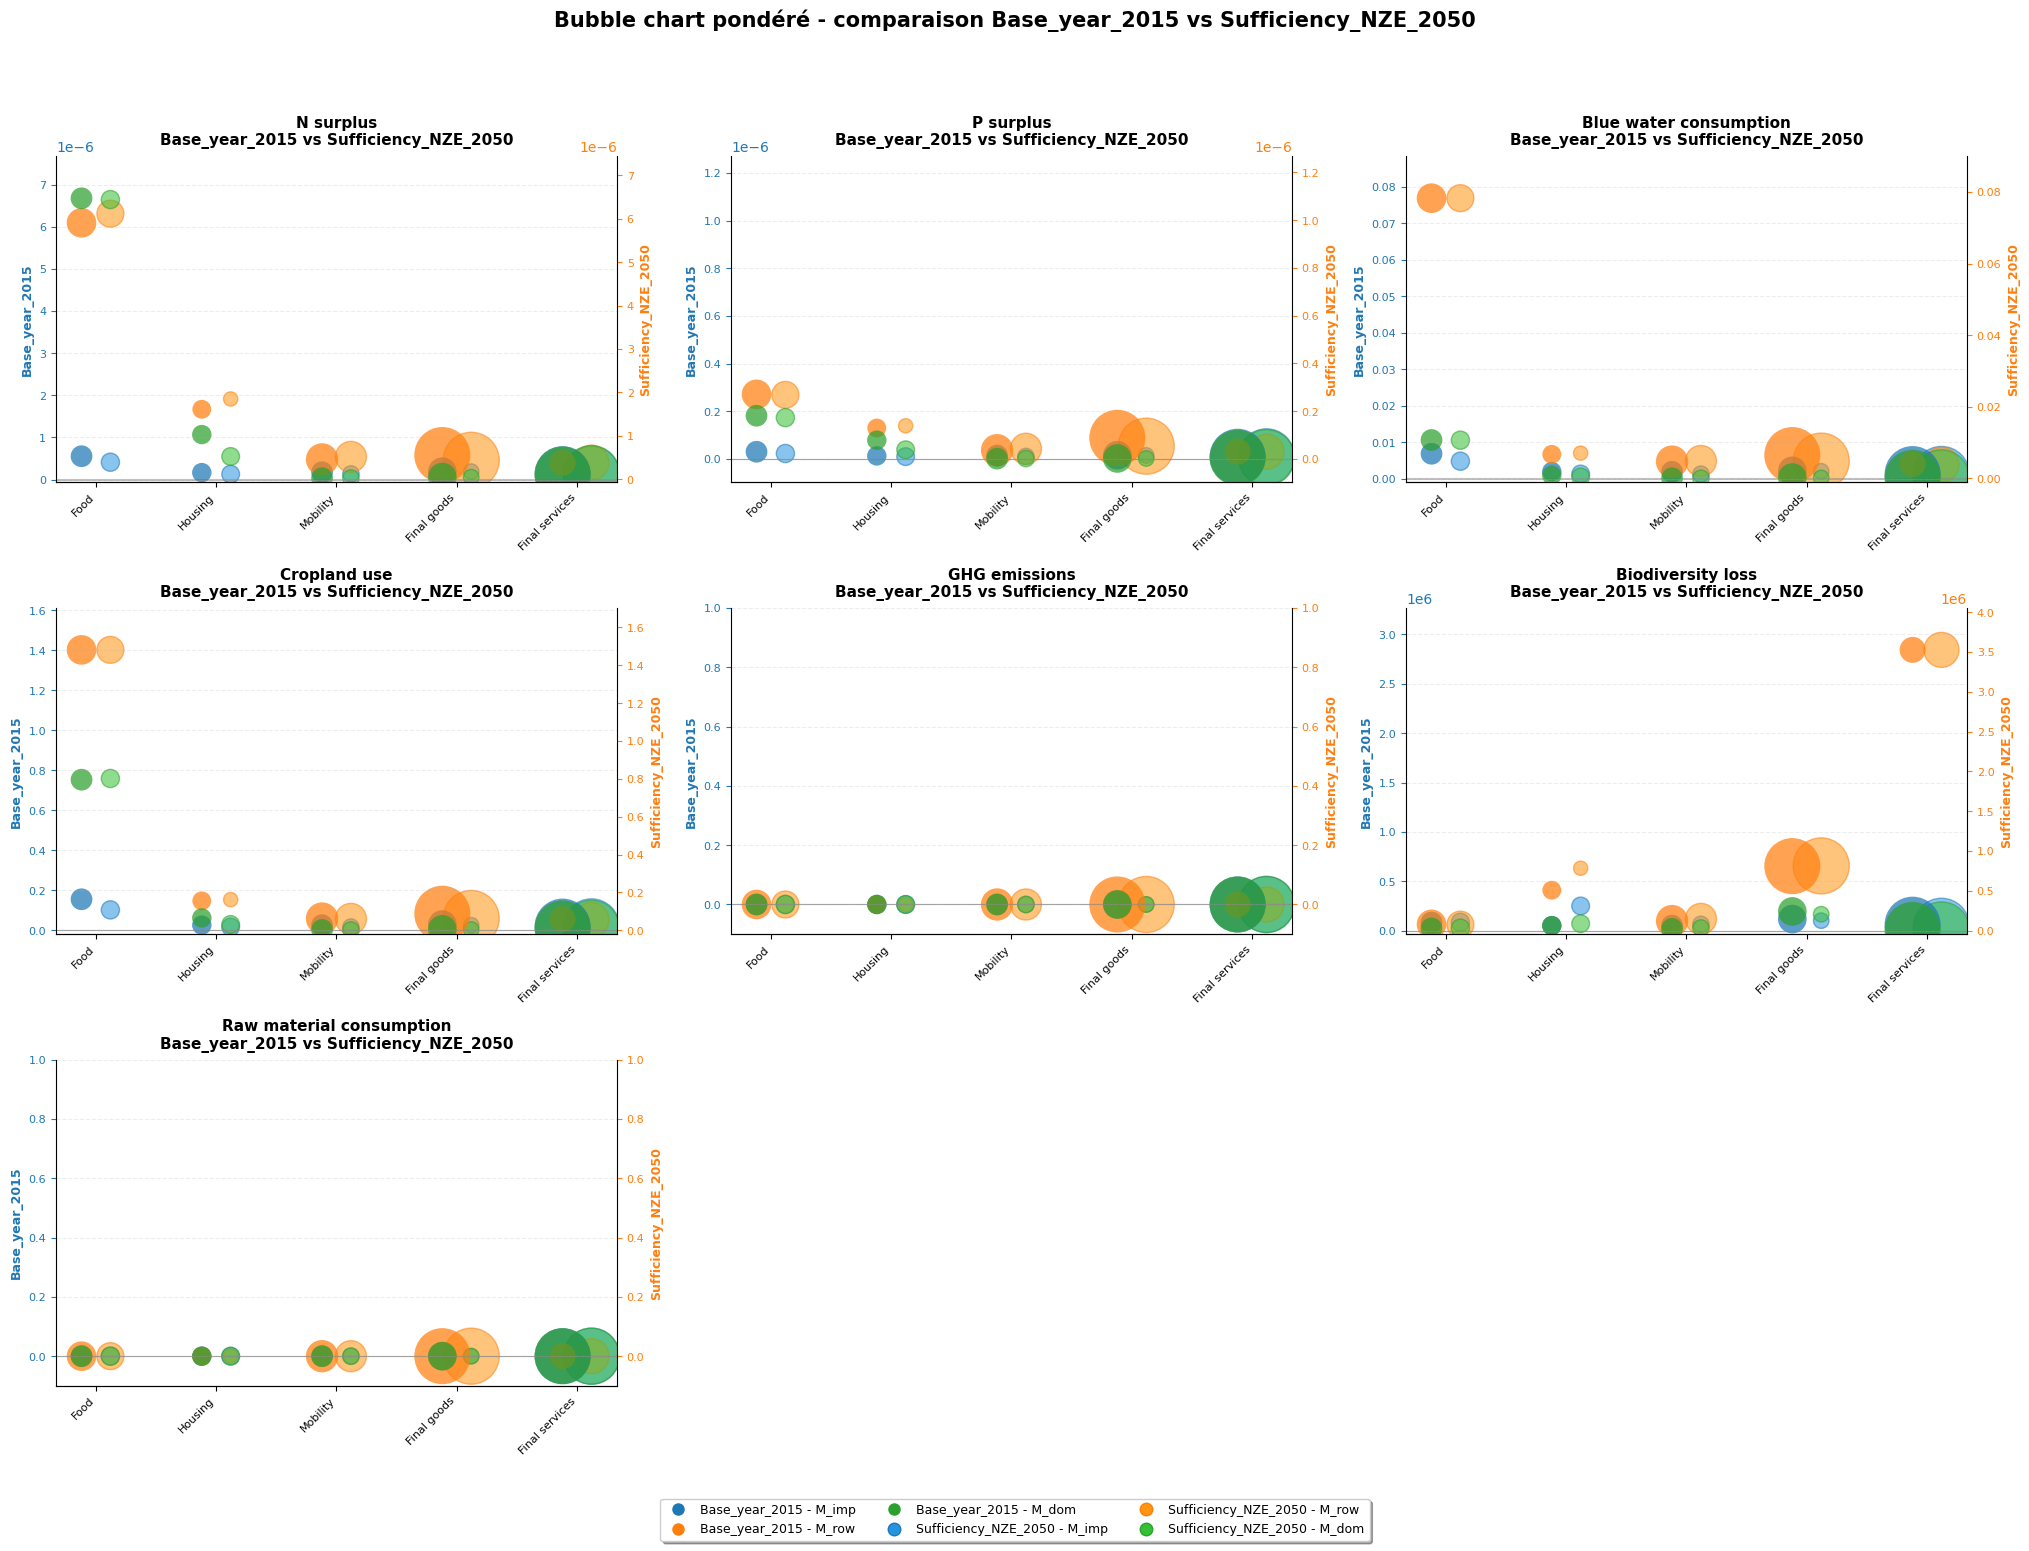

In [ ]:
COMPARISON_SCENARIO_NAME = "Sufficiency_NZE_2050"

comparison_folder = next((f for f in scenario_folders if f.name == COMPARISON_SCENARIO_NAME), None)
if comparison_folder is None:
    raise ValueError(
        f"Scénario '{COMPARISON_SCENARIO_NAME}' introuvable parmi {[f.name for f in scenario_folders]}"
    )

comparison_data, comparison_y_dom_cat, comparison_y_imp_cat = prepare_bubble_dataset(
    comparison_folder, facteurs_carac_df, bridge_m
)

fig_comparison, _ = plot_bubble_chart_comparison(
    base_data=data_bubble, base_y_dom_cat=y_dom_cat, base_y_imp_cat=y_imp_cat,
    s1_data=comparison_data, s1_y_dom_cat=comparison_y_dom_cat, s1_y_imp_cat=comparison_y_imp_cat,
    base_label=reference_folder.name, s1_label=comparison_folder.name,
)

output_path = config.FIGURES_DIR / f"bubble_chart_{reference_folder.name}_vs_{comparison_folder.name}_weighted.png"
fig_comparison.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Figure sauvegardée : {output_path}")